Import packages

In [63]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cobra
from cobra.io import read_sbml_model, write_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from tqdm import tqdm

In [64]:
from pathlib import Path
import plotly
import plotly.express as px
import scipy.stats

os.environ["OMP_NUM_THREADS"] = "1"  # because of a data leak of KMeans on windows
import fba_comparison_stats as cmp
from efflux_method import *
import networkx as nx
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

Import the models

How to make each models, how to put information in it? Efflux?

In [65]:
M_xanthus = read_sbml_model("../M_xanthus_model_V5_5.xml")

In [66]:
M_xanthus.metabolites.alaala_e.formula

'C6H12N2O3'

In [67]:
#Add importation constraints
M_xanthus.reactions.EX_alaala_e.lower_bound = 0
M_xanthus.reactions.EX_glu_L_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_co2_e.lower_bound = 0
M_xanthus.reactions.EX_lys_L_e.lower_bound = 0
M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_pheme_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_orn_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_fru_e.lower_bound = 0
M_xanthus.reactions.EX_for_e.lower_bound = 0

In [68]:
#TODO CONTINUE
liste_C = []
for i in M_xanthus.exchanges._dict:
    if "C" in M_xanthus.metabolites.get_by_id(M_xanthus.reactions.get_by_id("EX_met_L_e").reaction.split(" ")[0]).formula:
        liste_C.append(i)
        print("M_xanthus.reactions." + i + ".lower_bound = 0")

M_xanthus.reactions.EX_malt_e.lower_bound = 0
M_xanthus.reactions.EX_his_L_e.lower_bound = 0
M_xanthus.reactions.EX_cd2_e.lower_bound = 0
M_xanthus.reactions.EX_ferrich_e.lower_bound = 0
M_xanthus.reactions.EX_tttnt_e.lower_bound = 0
M_xanthus.reactions.EX_metox_e.lower_bound = 0
M_xanthus.reactions.EX_btn_e.lower_bound = 0
M_xanthus.reactions.EX_met_L_e.lower_bound = 0
M_xanthus.reactions.EX_mg2_e.lower_bound = 0
M_xanthus.reactions.EX_ac_e.lower_bound = 0
M_xanthus.reactions.EX_arsenb_e.lower_bound = 0
M_xanthus.reactions.EX_cbl1_e.lower_bound = 0
M_xanthus.reactions.EX_cgly_e.lower_bound = 0
M_xanthus.reactions.EX_fum_e.lower_bound = 0
M_xanthus.reactions.EX_h2s_e.lower_bound = 0
M_xanthus.reactions.EX_so4_e.lower_bound = 0
M_xanthus.reactions.EX_pydx_e.lower_bound = 0
M_xanthus.reactions.EX_spmd_e.lower_bound = 0
M_xanthus.reactions.EX_ppi_e.lower_bound = 0
M_xanthus.reactions.EX_mnl_e.lower_bound = 0
M_xanthus.reactions.EX_pro_L_e.lower_bound = 0
M_xanthus.reactions.EX_glyc3p_e.lo

In [69]:
M_xanthus.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Fe3_e,EX_Fe3_e,0.3066,0,0.00%
ca2_e,EX_ca2_e,0.07665,0,0.00%
cl_e,EX_cl_e,0.07665,0,0.00%
cobalt2_e,EX_cobalt2_e,0.07665,0,0.00%
cu2_e,EX_cu2_e,0.07665,0,0.00%
hdca_e,EX_hdca_e,200.2,16,92.64%
ile_L_e,EX_ile_L_e,11.18,6,1.94%
k_e,EX_k_e,0.07665,0,0.00%
leu_L_e,EX_leu_L_e,17.36,6,3.01%
mg2_e,EX_mg2_e,0.07665,0,0.00%


In [70]:
list_of_genes = []
for i in M_xanthus.genes:
    list_of_genes.append(i.id)

In [71]:
# Getting fluxes with constrains
dico = {
    14: "Alone",
    2: "P_E_coli_1-3",
    5: "P_B_subtilis",
    8: "P_Caulobacter",
    20: "P_E_coli_1-1",
}
for i in [14, 2, 5, 8, 20]:
    DictAP = read_csv_data(
        "/home/mickael/github/M_xanthus-E_coli-Predation/data/Raw/WT_vs_4preys_iMAT.csv",
        id_gene=1,
        id_val=i,
        list_of_genes=list_of_genes,
        head=True,
        quantile=0.95,
    )
    M_xanthus = read_sbml_model("../M_xanthus_model_V5_5.xml")
    #Add importation constraints
    for j in liste_C:
        M_xanthus.reactions.get_by_id(j).lower_bound = 0
    ## ESSENTIAL METABOLITES
    M_xanthus.reactions.EX_mg2_e.lower_bound = -1000
    M_xanthus.reactions.EX_h2s_e.lower_bound = -1000
    M_xanthus.reactions.EX_so4_e.lower_bound = -1000
    M_xanthus.reactions.EX_pydx_e.lower_bound = -1000
    M_xanthus.reactions.EX_spmd_e.lower_bound = -1000
    M_xanthus.reactions.EX_pi_e.lower_bound = -1000
    M_xanthus.reactions.EX_leu_L_e.lower_bound = -1000
    M_xanthus.reactions.EX_k_e.lower_bound = -1000
    M_xanthus.reactions.EX_cu2_e.lower_bound = -1000
    M_xanthus.reactions.EX_ca2_e.lower_bound = -1000
    M_xanthus.reactions.EX_zn2_e.lower_bound = -1000
    M_xanthus.reactions.EX_cl_e.lower_bound = -1000
    M_xanthus.reactions.EX_Fe3_e.lower_bound = -1000
    M_xanthus.reactions.EX_mn2_e.lower_bound = -1000
    M_xanthus.reactions.EX_nh4_e.lower_bound = -1000
    M_xanthus.reactions.EX_ile_L_e.lower_bound = -1000
    M_xanthus.reactions.EX_cobalt2_e.lower_bound = -1000
    M_xanthus.reactions.EX_val_L_e.lower_bound = -1000
    M_xanthus.reactions.EX_o2_e.lower_bound = -1000
    M_xanthus.reactions.EX_hdca_e.lower_bound = -1000
    Eflux(M_xanthus, DictAP, const=100, default_exp_val=1, ignore_human=True)
    M_xanthus.reactions.EX_glc_D_e.bounds = (0, 1000)
    model_c = M_xanthus.copy()
    write_sbml_model(
        model_c,
        "/home/mickael/github/M_xanthus-E_coli-Predation/fba_comparer-main/Models_Preda/M_xanthus_V4_efflux_"
        + dico[i]
        + ".xml",
    )
    print(dico[i] + " Done!")

Alone Done!
P_E_coli_1-3 Done!
P_B_subtilis Done!
P_Caulobacter Done!
P_E_coli_1-1 Done!


In [72]:
M_xanthus_alone = read_sbml_model("Models_Preda/M_xanthus_V4_efflux_Alone.xml")
solution_alone = M_xanthus_alone.optimize()

In [73]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-3.xml"
)
solution_predation_E_3 = M_xanthus_predation.optimize()

In [74]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_B_subtilis.xml"
)
solution_predation_B = M_xanthus_predation.optimize()

In [75]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_Caulobacter.xml"
)
solution_predation_C = M_xanthus_predation.optimize()

In [76]:
M_xanthus_predation = read_sbml_model(
    "Models_Preda/M_xanthus_V4_efflux_P_E_coli_1-1.xml"
)
solution_predation_E_1 = M_xanthus_predation.optimize()

In [77]:
print(f"Alone:\t{solution_alone.objective_value}")
print(f"Predation E.coli 1/1 :\t{solution_predation_E_1.objective_value}")
print(f"Predation E.coli 1/3 :\t{solution_predation_E_3.objective_value}")
print(f"Predation B_subtilis:\t{solution_predation_B.objective_value}")
print(f"Predation Caulobacter:\t{solution_predation_C.objective_value}")

Alone:	0.20445275853613284
Predation E.coli 1/1 :	0.16754778715563934
Predation E.coli 1/3 :	0.1016551738142416
Predation B_subtilis:	0.12641156146725457
Predation Caulobacter:	0.16752521568295672


## **FBA Comparer**
**Create combined dataframe and preprocess data**

Filter all reactions where fluxes are zero:

In [78]:
solutions = [
    solution_alone,
    solution_predation_E_1,
    solution_predation_E_3,
    solution_predation_B,
    solution_predation_C,
]
conditions = [
    "Alone",
    "Predation E.coli 1/1",
    "Predation E.coli 1/3",
    "Predation B. subtilis",
    "Predation Caulobacter",
]
obj_values = [
    solution_alone.objective_value,
    solution_predation_E_1.objective_value,
    solution_predation_E_3.objective_value,
    solution_predation_B.objective_value,
    solution_predation_C.objective_value,
]

mxanthus = cmp.build_dataframe(M_xanthus_alone, solutions, conditions)
mxanthus_filtered = cmp.filter_dataframe(mxanthus, conditions, rounding=True)
print(f"Number of reactions in the models: {len(mxanthus)}")
print(f"Number of nonzero reactions in the models: {len(mxanthus_filtered)}")

Number of reactions in the models: 1339
Number of nonzero reactions in the models: 481


normalize data:

In [79]:
mxanthus_normalized = cmp.normalize_dataframe_cols(
    mxanthus_filtered, conditions, obj_values
)  # biomass normalization
mxanthus_normalized_div_by_max = cmp.normalize_dataframe_rows(
    mxanthus_normalized, conditions, "div_by_max"
)  # normalization reactions
# note: there is no difference between the order of div_by_max normalization and filtering for changing reactions
mxanthus_normalized_div_by_max_changing = mxanthus_normalized_div_by_max[
    mxanthus_normalized_div_by_max["Std_dev"] >= 0.01
]  # keep only reactions that change
print(
    f"Number of normalized changing reactions: {len(mxanthus_normalized_div_by_max_changing)}"
)

Number of normalized changing reactions: 155


## Identify reactions with most/least variation

Most affected / change reaction

In [82]:
most_variable_bar_plot = cmp.bar_plot_flux_variation(
    mxanthus_normalized, conditions, 0, 10
)
most_variable_bar_plot.show()

In [83]:
sorted_flux = mxanthus_normalized[["ID", "Name", "Std_dev"]].sort_values(
    by=["Std_dev"], ascending=False
)
sorted_flux["Kegg"] = [
    M_xanthus_alone.reactions.get_by_id(id).__dict__["_annotation"].get("kegg.reaction")
    for id in sorted_flux["ID"]
]
sorted_flux[0:10]

,ID,Name,Std_dev,Kegg
364,rxn00182_c,L-glutamate:NAD+ oxidoreductase (deaminating) [c],16.136494,R00243
720,rxn00260_c,L-Aspartate:2-oxoglutarate aminotransferase [c],15.710118,R00355
58,rxn00262_c,L-Aspartic acid:oxygen oxidoreductase (deamina...,14.986208,R00357
469,rxn00006_c,hydrogen-peroxide:hydrogen-peroxide oxidoreduc...,13.692922,R00009
535,rxn00066_c,NADH:hydrogen-peroxide oxidoreductase [c],10.449952,R00090
1246,EX_ac_e,Exchange for Acetate [e],9.406047,None
1180,rxn05488_c,acetate reversible transport via proton sympor...,9.406047,None
32,rxn00172_c,Acetate:CoA ligase (ADP-forming) [c],8.229836,R00229
1055,rxn05638_c,TRANS-RXNBWI-115637.ce.maizeexp.PRO_PRO [c],7.863283,None
1146,rxn09193_c,L-proline transport via diffusion (extracellul...,7.863283,None


In [144]:
M_xanthus.reactions.rxn09193_c

Reaction identifier,rxn09193_c
Name,L-proline transport via diffusion (extracellular to periplasm) [c]
Memory address,0x788b95decbc0
Stoichiometry,pro_L_e <=> pro_L_c L-Proline [e] <=> L-Proline [c]
GPR,MXAN_6841
Lower bound,-3.1363824927858697
Upper bound,3.1363824927858697


In [145]:
M_xanthus.metabolites.accoa_c.summary()

Percent,Flux,Reaction,Definition
15.64%,0.6695,rxn00178_c,2.0 accoa_c <=> aacoa_c + coa_c
7.87%,0.3369,rxn00256_c,cit_c + coa_c + h_c <=> accoa_c + h2o_c + oaa_c
11.40%,0.4882,rxn00330_c,coa_c + h_c + mal_L_c <=> accoa_c + glx_c + h2o_c
8.23%,0.3522,rxn00676_c,accoa_c + ppcoa_c <=> 2maacoa_c + coa_c
9.35%,0.4003,rxn00874_c,accoa_c + btcoa_c <=> 3ohcoa_c + coa_c
9.35%,0.4003,rxn02680_c,accoa_c + occoa_c <=> 3odcoa_c + coa_c
9.98%,0.4272,rxn02804_c,accoa_c + tdcoa_c <=> 3ohdcoa_c + coa_c
9.35%,0.4003,rxn03243_c,accoa_c + dccoa_c <=> 3oddcoa_c + coa_c
9.35%,0.4003,rxn03248_c,accoa_c + hxcoa_c <=> 3oocoa_c + coa_c
9.48%,0.4057,rxn06510_c,accoa_c + ddcoa_c <=> 3otdcoa_c + coa_c


In [142]:
M_xanthus.metabolites.h2o2_c

Metabolite identifier,h2o2_c
Name,H2O2 [c]
Memory address,0x788b97aaaab0
Formula,H2O2
Compartment,c
In 17 reaction(s),"rxn20627_c, rxn00262_c, rxn00206_c, rxn00205_c, rxn00208_c, rxn23045_c, rxn00209_c, rxn00066_c, rxn01833_c, rxn00006_c, rxn00014_c, rxn00269_c, rxn07295_c, rxn09296_c, rxn00338_c, rxn02946_c,..."


In [87]:
from bioservices import KEGG

k = KEGG()

for rxn in M_xanthus.reactions:
    if "kegg.reaction" in rxn.annotation:
        kegg_id = rxn.annotation["kegg.reaction"]
        try:
            data = k.get(kegg_id)
            parsed = k.parse(data)
            if "PATHWAY" in parsed:
                rxn.subsystem = list(parsed["PATHWAY"].values())[0]
        except:
            continue

WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02371)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R01549)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02097)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R02292)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00962)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https://rest.kegg.jp/get/R00967)
WARNING [bioservices.KEGG:1210]:  Could not parse the entry correctly.
WARNING [bioservices.KEGG:535]:  HTTP 404 Not Found (https

**LOOKING STUFF**

In [146]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Glyoxylate and dicarboxylate metabolism":
        liste.append(i)

sorted_flux.loc[sorted_flux["ID"].isin(liste)]

,ID,Name,Std_dev,Kegg
469,rxn00006_c,hydrogen-peroxide:hydrogen-peroxide oxidoreduc...,1.369292e+01,R00009
277,rxn00336_c,isocitrate glyoxylate-lyase (succinate-forming...,1.286562e+00,R00479
1215,rxn00979_c,glycolaldehyde:NAD+ oxidoreductase,5.304378e-16,R01333


Pathway analysis

In [147]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(liste)] #Glycolysis / Gluconeogenesis

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
277,rxn00336_c,rxn00336_c: icit_c <=> glx_c + succ_c,isocitrate glyoxylate-lyase (succinate-forming...,-1.329428,-1.875687,-4.298676,-3.920111,-2.475375,1.286562e+00,-2.779855
469,rxn00006_c,rxn00006_c: 2.0 h2o2_c <=> 2.0 h2o_c + o2_c,hydrogen-peroxide:hydrogen-peroxide oxidoreduc...,0.184280,3.166300,26.593052,27.012941,2.299273,1.369292e+01,11.851169
1215,rxn00979_c,rxn00979_c: gcald_c + h2o_c + nad_c --> glyclt...,glycolaldehyde:NAD+ oxidoreductase,0.004800,0.004800,0.004800,0.004800,0.004800,5.304378e-16,0.004800


In [153]:
M_xanthus.reactions.rxn00979_c

Reaction identifier,rxn00979_c
Name,glycolaldehyde:NAD+ oxidoreductase
Memory address,0x788b8eb7bc80
Stoichiometry,gcald_c + h2o_c + nad_c --> glyclt_c + 2.0 h_c + nadh_c Glycolaldehyde [c] + H2O [c] + NAD [c] --> Glycolate [c] + 2.0 H+ [c] + NADH [c]
GPR,
Lower bound,0
Upper bound,100.0


In [148]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Arginine biosynthesis":
        liste.append(i)

sorted_flux.loc[sorted_flux["ID"].isin(liste)]

,ID,Name,Std_dev,Kegg
364,rxn00182_c,L-glutamate:NAD+ oxidoreductase (deaminating) [c],1.613649e+01,R00243
720,rxn00260_c,L-Aspartate:2-oxoglutarate aminotransferase [c],1.571012e+01,R00355
462,rxn00187_c,L-Glutamate:ammonia ligase (ADP-forming) [c],2.387975e-01,R00253
607,rxn00184_c,L-Glutamate:NADP+ oxidoreductase (deaminating)...,1.308324e-02,R00248
1044,rxn01019_c,Carbamoyl-phosphate:L-ornithine carbamoyltrans...,6.221832e-16,R01398
182,rxn00802_c,2-(Nomega-L-arginino)succinate arginine-lyase ...,6.173666e-16,R01086
883,rxn01434_c,L-Citrulline:L-aspartate ligase (AMP-forming) [c],6.001241e-16,R01954
518,rxn00113_c,"Carbon-dioxide:ammonia ligase (ADP-forming,car...",5.049684e-16,R00149


In [149]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(liste)]

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
182,rxn00802_c,rxn00802_c: argsuc_c <=> arg_L_c + fum_c,2-(Nomega-L-arginino)succinate arginine-lyase ...,0.238104,0.238104,0.238104,0.238104,0.238104,6.173666e-16,0.238104
364,rxn00182_c,rxn00182_c: glu_L_c + h2o_c + nad_c <=> akg_c ...,L-glutamate:NAD+ oxidoreductase (deaminating) [c],-39.367656,-34.685503,-60.103474,-73.810867,-44.850632,1.613649e+01,-50.563626
462,rxn00187_c,rxn00187_c: atp_c + glu_L_c + nh4_c --> adp_c ...,L-Glutamate:ammonia ligase (ADP-forming) [c],0.865298,0.773208,0.781805,0.320383,0.446708,2.387975e-01,0.637481
518,rxn00113_c,rxn00113_c: 2.0 atp_c + co2_c + h2o_c + nh4_c ...,"Carbon-dioxide:ammonia ligase (ADP-forming,car...",0.409877,0.409877,0.409877,0.409877,0.409877,5.049684e-16,0.409877
607,rxn00184_c,rxn00184_c: glu_L_c + h2o_c + nadp_c <=> akg_c...,L-Glutamate:NADP+ oxidoreductase (deaminating)...,0.000000,0.000000,0.000000,0.000000,0.029255,1.308324e-02,0.005851
720,rxn00260_c,rxn00260_c: akg_c + asp_L_c <=> glu_L_c + oaa_c,L-Aspartate:2-oxoglutarate aminotransferase [c],-36.118239,-31.343996,-56.770564,-70.016536,-45.351652,1.571012e+01,-47.920197
883,rxn01434_c,rxn01434_c: asp_L_c + atp_c + citr_L_c <=> amp...,L-Citrulline:L-aspartate ligase (AMP-forming) [c],0.238104,0.238104,0.238104,0.238104,0.238104,6.001241e-16,0.238104
1044,rxn01019_c,rxn01019_c: cbp_c + orn_c --> citr_L_c + h_c +...,Carbamoyl-phosphate:L-ornithine carbamoyltrans...,0.238104,0.238104,0.238104,0.238104,0.238104,6.221832e-16,0.238104


In [151]:
liste = []
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Fatty acid degradation":
        liste.append(i)

filter = sorted_flux.loc[sorted_flux["ID"].isin(liste)][0:100]["ID"]
sorted_flux.loc[sorted_flux["ID"].isin(liste)]

,ID,Name,Std_dev,Kegg
189,rxn02720_c,"Lauroyl-CoA:(acceptor) 2,3-oxidoreductase [c]",5.399770,R03857
447,rxn03253_c,"Decanoyl-CoA:(acceptor) 2,3-oxidoreductase [c]",3.744209,R04754
948,rxn00946_c,Palmitoyl-CoA:oxygen 2-oxidoreductase [c],3.600274,R01279
721,rxn02803_c,"Tetradecanoyl-CoA:(acceptor) 2,3-oxidoreductas...",3.490229,R03990
196,rxn00178_c,Acetyl-CoA:acetyl-CoA C-acetyltransferase [c],2.299194,R00238
170,rxn01451_c,(S)-3-Hydroxybutanoyl-CoA:NAD+ oxidoreductase [c],0.832898,R01975
971,rxn02167_c,(S)-3-Hydroxybutanoyl-CoA hydro-lyase [c],0.832898,R03026
528,rxn00872_c,Butanoyl-CoA:oxygen 2-oxidoreductase [c],0.832898,R01175
956,rxn03251_c,"Hexanoyl-CoA:(acceptor) 2,3-oxidoreductase [c]",0.832898,R04751


In [152]:
mxanthus_normalized.loc[mxanthus_normalized["ID"].isin(filter)] 

,ID,Reaction,Name,Alone,Predation E.coli 1/1,Predation E.coli 1/3,Predation B. subtilis,Predation Caulobacter,Std_dev,Mean
170,rxn01451_c,rxn01451_c: 3hbycoa_c + nad_c <=> aacoa_c + h_...,(S)-3-Hydroxybutanoyl-CoA:NAD+ oxidoreductase [c],5.412970,4.053413,4.114195,5.829163,5.488089,0.832898,4.979566
189,rxn02720_c,rxn02720_c: ddcoa_c + fad_c + h_c <=> fadh2_c ...,"Lauroyl-CoA:(acceptor) 2,3-oxidoreductase [c]",0.000000,0.000000,0.000000,-7.307980,-11.610601,5.399770,-3.783716
196,rxn00178_c,rxn00178_c: 2.0 accoa_c <=> aacoa_c + coa_c,Acetyl-CoA:acetyl-CoA C-acetyltransferase [c],-5.021697,-3.662140,-3.722922,-5.437890,-9.295097,2.299194,-5.427949
447,rxn03253_c,rxn03253_c: dccoa_c + fad_c + h_c <=> dc2coa_c...,"Decanoyl-CoA:(acceptor) 2,3-oxidoreductase [c]",-8.372306,0.000000,0.000000,0.000000,0.000000,3.744209,-1.674461
528,rxn00872_c,rxn00872_c: btcoa_c + fad_c + h_c <=> b2coa_c ...,Butanoyl-CoA:oxygen 2-oxidoreductase [c],5.412970,4.053413,4.114195,5.829163,5.488089,0.832898,4.979566
721,rxn02803_c,rxn02803_c: fad_c + h_c + tdcoa_c <=> fadh2_c ...,"Tetradecanoyl-CoA:(acceptor) 2,3-oxidoreductas...",0.000000,-7.928893,0.000000,0.000000,-3.385926,3.490229,-2.262964
948,rxn00946_c,rxn00946_c: fad_c + h_c + pmtcoa_c <=> fadh2_c...,Palmitoyl-CoA:oxygen 2-oxidoreductase [c],0.000000,0.000000,-8.050457,0.000000,0.000000,3.600274,-1.610091
956,rxn03251_c,rxn03251_c: fad_c + h_c + hxcoa_c <=> fadh2_c ...,"Hexanoyl-CoA:(acceptor) 2,3-oxidoreductase [c]",5.412970,4.053413,4.114195,5.829163,5.488089,0.832898,4.979566
971,rxn02167_c,rxn02167_c: 3hbycoa_c <=> b2coa_c + h2o_c,(S)-3-Hydroxybutanoyl-CoA hydro-lyase [c],-5.412970,-4.053413,-4.114195,-5.829163,-5.488089,0.832898,-4.979566


In [158]:
M_xanthus.reactions.rxn00178_c

Reaction identifier,rxn00178_c
Name,Acetyl-CoA:acetyl-CoA C-acetyltransferase [c]
Memory address,0x788b9c827230
Stoichiometry,2.0 accoa_c <=> aacoa_c + coa_c 2.0 Acetyl-CoA [c] <=> Acetoacetyl-CoA [c] + CoA [c]
GPR,MXAN_6988 or (MXAN_3791 and MXAN_5372 and MXAN_2963 and MXAN_5883) or (MXAN_3791 and MXAN_5883)...
Lower bound,-57.71308482364697
Upper bound,57.71308482364697


**Pathway analysis**

In [94]:
M_xanthus.metabolites.uacgam_c.summary()

Percent,Flux,Reaction,Definition
100.00%,0.0215,rxn00293_c,acgam1p_c + h_c + utp_c --> ppi_c + uacgam_c
Percent,Flux,Reaction,Definition
25.00%,-0.005375,rxn00461_c,pep_c + uacgam_c --> pi_c + uaccg_c
25.00%,-0.005375,rxn03408_c,uacgam_c + uagmda_c --> h_c + uaagmda_c + udp_c
50.00%,-0.01075,rxn06729_c,3htdACP_c + uacgam_c <=> ACP_c + u3aga_c


In [95]:
pathway_dict_M = {}
for i in M_xanthus.reactions:
    if i.subsystem in pathway_dict_M:
        pathway_dict_M[i.subsystem].append(i.id)
    else:
        pathway_dict_M[i.subsystem] = [i.id]

In [96]:
pw_list = cmp.pathway_variability(
    mxanthus_normalized, pathway_dict_M, ascending=True, num=10
)

Glyoxylate and dicarboxylate metabolism		 -> 4.99 (contains 3 reactions)
Arginine biosynthesis		 -> 4.01 (contains 8 reactions)
Fatty acid degradation		 -> 2.43 (contains 9 reactions)
Alanine, aspartate and glutamate metabolism		 -> 2.31 (contains 7 reactions)
Lysine degradation		 -> 1.57 (contains 1 reactions)
Butanoate metabolism		 -> 1.57 (contains 1 reactions)
Valine, leucine and isoleucine degradation		 -> 1.48 (contains 17 reactions)
		 -> 1.06 (contains 159 reactions)
Fatty acid elongation		 -> 0.93 (contains 19 reactions)
Citrate cycle (TCA cycle)		 -> 0.84 (contains 8 reactions)


In [97]:
for i in M_xanthus.reactions._dict:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Glycolysis / Gluconeogenesis":
        print(i)

rxn02342_c
rxn00172_c
rxn00545_c
rxn00148_c
rxn00781_c
rxn00549_c
rxn00506_c
rxn00305_c
rxn00747_c
rxn00147_c
rxn01871_c
rxn00786_c
rxn01100_c
rxn01106_c
rxn00543_c
rxn00011_c
rxn00459_c
rxn00175_c
rxn01171_c
rxn15249_c
rxn20583_c


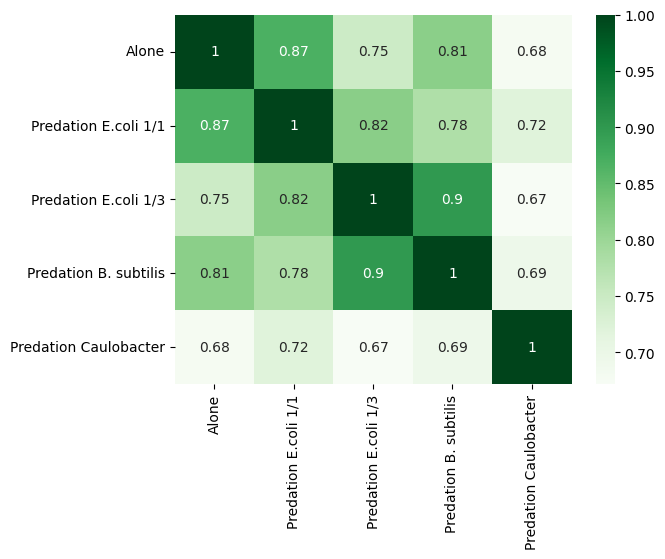

In [98]:
fig_r = cmp.correlation_matrix(
    mxanthus_normalized_div_by_max_changing, conditions, color="Greens"
)

## Flux correlation network

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

In [100]:
corr_matrix = cmp.flux_coupling_matrix(
    mxanthus_normalized_div_by_max, conditions, remove_unchanging=0.01, abs_values=True
)

326 reaction were removed, because their Std_dev is lower than 0.01
The following 6 reactions were removed because they swap signs across conditions: ['rxn08172_c', 'rxn05466_c', 'rxn01454_c', 'rxn04142_c', 'rxn00274_c', 'EX_nh4_e']


In [101]:
mask = []
for i in corr_matrix:
    if M_xanthus.reactions.get_by_id(i).subsystem == "Purine metabolism":
        mask.append(i)

new = corr_matrix.filter(mask, axis=0)
corr_matrix_filter = new.filter(mask, axis=1)

corr_matrix_filter

,rxn00097_c,rxn00379_c
rxn00097_c,1.000000,-0.021864
rxn00379_c,-0.021864,1.000000


In [102]:
# plt.figure(figsize=(16,12))
# sns.heatmap(corr_matrix_filter, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# plt.title("Correlation Heatmap")
# plt.show()

In [103]:
# Correlation network
nw = cmp.flux_coupling_network(corr_matrix, pc=0.7)
fig = cmp.visualize_interactive_network(nw, mxanthus_normalized_div_by_max, conditions)
fig.show()

Created Flux Coupling network with pc threshold 0.7.
Number of nodes: 149
Number of edges: 1976
Number of connected components: 3


In [104]:
# # Colored pathway network
# nw3 = nw
# cmp.color_network_by_pathway(
#     nw3, pathway= "Purine metabolism", pathway_dict= pathway_dict_M
# )  # takes edge weights into account!

# fig = cmp.visualize_interactive_network(nw3, mxanthus_normalized_div_by_max, conditions)
# fig.show()

In [105]:
# Colored community network
nw2 = nw
cmp.color_network_by_communities(
    nw2, 8, include_weights=True
)  # takes edge weights into account!

comm_map = cmp.get_community_list(nw)
color = cmp.get_color_map(comm_map)

fig = cmp.visualize_interactive_network(nw2, mxanthus_normalized_div_by_max, conditions)
fig.show()

Community map

In [106]:
fig = cmp.community_bar_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()

In [107]:
fig = cmp.community_box_plots(mxanthus_normalized_div_by_max, conditions, comm_map)
fig.show()

In [108]:
with open("pathway_information/mxanthus_filtered_ids.tsv", "w") as file:
    for line in M_xanthus.reactions:
        file.write(line.id + "\n")

In [109]:
## load ID dictionary (mapping ids to pathways)
filtered_ids = []
with open("pathway_information/mxanthus_filtered_ids.tsv", "r") as file:
    for line in file:
        filtered_ids.append(line.strip())
id_dict = {}
with open("pathway_information/ecoli_map_id_to_pathway.tsv", "r") as file: #TODO REDO THIS FILE FOR MYXO / line correspond to mxanthus_filtered_ids
    for id, line in zip(filtered_ids, file):
        if line == "\n":
            continue
        words = line.strip().split("\t")
        id_dict[id] = words

pathway_hierarchy = {}
with open("pathway_information/kegg_pathway_hierarchy.txt", "r") as file:
    for line in file:
        line = line.rstrip("\n")
        words = line.replace("_", " ").split("\\t")
        pathway_hierarchy[words.pop(0)] = words

In [110]:
# sankey diagram of KEGG pathway categories
fig = cmp.community_sankey_diagram(
    comm_map,
    list(pathway_hierarchy.keys()),
    mxanthus_normalized_div_by_max,
    id_dict,
    diagram_height=1000,
    pw_hierarchy=pathway_hierarchy,
    text_size=16,
)
fig.show()

Look for community 1, 2 and 3

Try also for 7 and 10

In [111]:
for i in comm_map:
    print(i)

#FD3216
#00FE35
#6A76FC
#FED4C4
#FE00CE
#0DF9FF
#F6F926
#FF9616
#479B55
#EEA6FB
#DC587D


In [159]:
# Community 1
Genes_list_1 = []
for i in comm_map["#FD3216"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_1:
            Genes_list_1.append(str(j))

with open('Genes_list_1.txt', 'w') as f:
    for line in Genes_list_1:
        f.write(f"{line}\n")

In [160]:
# Community 2
Genes_list_2 = []
for i in comm_map["#00FE35"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_2:
            Genes_list_2.append(str(j))

with open('Genes_list_2.txt', 'w') as f:
    for line in Genes_list_2:
        f.write(f"{line}\n")

In [161]:
# Community 3
Genes_list_3 = []
for i in comm_map["#6A76FC"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_3:
            Genes_list_3.append(str(j))

with open('Genes_list_3.txt', 'w') as f:
    for line in Genes_list_3:
        f.write(f"{line}\n")

In [162]:
# Community 5
Genes_list_5 = []
for i in comm_map["#FE00CE"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_5:
            Genes_list_5.append(str(j))

with open('Genes_list_5.txt', 'w') as f:
    for line in Genes_list_5:
        f.write(f"{line}\n")

In [163]:
# Community 7
Genes_list_7 = []
for i in comm_map["#F6F926"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_7:
            Genes_list_7.append(str(j))

with open('Genes_list_7.txt', 'w') as f:
    for line in Genes_list_7:
        f.write(f"{line}\n")

In [164]:
# Community 8
Genes_list_8 = []
for i in comm_map["#FF9616"]:
    for j in M_xanthus.reactions.get_by_id(i).genes:
        if str(j) not in Genes_list_8:
            Genes_list_8.append(str(j))

with open('Genes_list_8.txt', 'w') as f:
    for line in Genes_list_8:
        f.write(f"{line}\n")